In [67]:
import pandas as pd
import glob 
import numpy as np
import protfasta
from ete4 import Tree
from ete4.treeview import TreeStyle, TextFace, NodeStyle
import tqdm


## Adding species to CL sequences

In [2]:
cl_seqs = protfasta.read_fasta("../output/cl_seqs.fasta", invalid_sequence_action='remove')
cl_seqs_df = pd.DataFrame({"id": cl_seqs.keys(), "seq": cl_seqs.values()})
cl_seqs_df.head()

,id,seq
0,g002981.m1_ashbya_aceri.final,MNRSDELQDAEDSGQQRYETYSCSRCRRLKKRCSKELPRCFSCEAA...
1,g001536.m1_brettanomyces_anomalus.final,MSDKPHNQYACTRCRRLKKKCSKEFPRCANCRKQNKVCEYVERKNK...
2,C1_01200W_A_candida_albicans.cgd,MRPIDSIVSKFRVQKHTSNLADNPAVLKHPEDMPKLTSCLRCRKLK...
3,g000106.m1_candida_albicans.final,MRPIDSIVSKFRVQKHTSNLADNPAVLKHPEDMPKLTSCLRCRKLK...
4,g001050.m1_candida_dubliniensis.final,MRPTDSIVSKFRVQKPTSNLANNPAVLRHPENMPKLTSCLRCRKLK...


In [3]:
cl_seqs_df[cl_seqs_df["id"].str.contains("_sp_")]

,id,seq
89,g005938.m1_yHDO568_nakaseomyces_sp_190924.final,MSEDSSDLYNNEALEAYSCSRCRKLKKKCPRQLPQCSNCAKAREIC...
90,g003773.m1_yHDO569_candida_sp_180604.final,MNHPQAAAGYQVLQTTGLTPERNRKDHAASDLDRLSMISKFRMKPS...
93,g000862.m1_yHDO576_kazachstania_sp_180604.final,MSGSESDPKLEAYSCARCRRLKKKCSRELPICSHCTRSKKECVYPG...
101,g004599.m1_yHDO592_zygotorulaspora_sp_190924.f...,METEGEPTVPVKYEAYSCSRCRRLKKRCTKESPKCKNCTKAGEECV...
102,g002325.m1_yHDO593_barnettozyma_sp_180604.final,MSNINTLMNYDQQKDDKEEFSSPGNEDLEKRTYSCKRCRRLKKKCS...
...,...,...
172778,g000345.m1_yHKB289_Vanderwaltozyma_sp_nov_plat...,MPMPGETEDENKTLRNDTLGNDTIGNDDTLGNNSLFDYLDGLDLDL...
172779,g003058.m1_yHMH443_Groenewaldozyma_sp_nov_plat...,METAPRNHVRELPASIAQLPSEFSTAEEHKPANSNNYYCPPPFSVP...
172780,g005684.m1_yHMH660_Kluyveromyces_sp_nov_plate3...,MEPHNDSGLGSLLDMDLEGLDFETAYEMINEKAEFWGEHHDHDQMD...
172781,g004638.m1_yHMJ407_Torulaspora_sp_nov_plate34_...,MESVPDLDLLDSFGLENDKEIDFETAYRMISNFDEDLSRPQNDSML...


In [4]:
for id in cl_seqs_df["id"].sample(10):
    print(id)

g005558.m1_yHMPu5000034998_cephaloascus_albidus_160519.haplomerger2.final
g007770.m1_yHMPu5000037918_alloascoidea_africana_180604.final
g001098.m1_yHMPu5000037219_Pichia_gijzenarium_SPADES.final
g000633.m1_yHMPu5000037893_candida_ovalis_170912.final
g000030.m1_yHMPu5000038115_candida_aurita_170912.final
g004637.m1_yHMPu5000034598_Candida_dendrica_SPADES.final
g000229.m1_yHMPu5000035705_candida_pseudohaemulonii_160613.final
g004861.m1_yHMPu5000040956_metschnikowia_borealis_201018.final
g002960.m1_yHMPu5000035293_saturnispora_diversa_170307.final
g005345.m1_yHMPu5000034599_candida_berthetii_190924.haplomerger2.final


In [5]:
cl_seqs_df_regex = cl_seqs_df["id"].str.extract(r'_([a-zA-Z]{2,})_([a-zA-Z]{2,})?')
cl_seqs_df_regex[1] = cl_seqs_df_regex[1].replace({"sp" : ""})
cl_seqs_df_regex = cl_seqs_df_regex.fillna("")
cl_seqs_df_regex

,0,1
0,ashbya,aceri
1,brettanomyces,anomalus
2,candida,albicans
3,candida,albicans
4,candida,dubliniensis
...,...,...
172849,Vanderwaltozyma,verrucispora
172850,kazachstania,turicensis
172851,lachancea,quebecuensis
172852,Lachancea,


In [6]:
cl_seqs_df["species"] = cl_seqs_df_regex[0] + " " + cl_seqs_df_regex[1]
cl_seqs_df

,id,seq,species
0,g002981.m1_ashbya_aceri.final,MNRSDELQDAEDSGQQRYETYSCSRCRRLKKRCSKELPRCFSCEAA...,ashbya aceri
1,g001536.m1_brettanomyces_anomalus.final,MSDKPHNQYACTRCRRLKKKCSKEFPRCANCRKQNKVCEYVERKNK...,brettanomyces anomalus
2,C1_01200W_A_candida_albicans.cgd,MRPIDSIVSKFRVQKHTSNLADNPAVLKHPEDMPKLTSCLRCRKLK...,candida albicans
3,g000106.m1_candida_albicans.final,MRPIDSIVSKFRVQKHTSNLADNPAVLKHPEDMPKLTSCLRCRKLK...,candida albicans
4,g001050.m1_candida_dubliniensis.final,MRPTDSIVSKFRVQKPTSNLANNPAVLRHPENMPKLTSCLRCRKLK...,candida dubliniensis
...,...,...,...
172849,g003574.m1_yHMPu5000037837_Vanderwaltozyma_ver...,MDTTNSLFDSINTITTTNLSTSSTTTDNVKDFNNLFDDDFDLGIDF...,Vanderwaltozyma verrucispora
172850,g000938.m1_yHMPu5000040961_kazachstania_turice...,MQHHNMELDNLFDLDADIDFETAYQLFSNLDNIQEKNIDIFTQNVH...,kazachstania turicensis
172851,g003697.m1_yHMPu5000040963_lachancea_quebecuen...,MDTDRLLDIFDFDLEIDFETAYEMINKEDQNAKHATERSLVENEVD...,lachancea quebecuensis
172852,g004154.m1_yHQL494_Lachancea_sp_nov_plate34_PL...,MENEHLLDVFDYDLDIDFETAYEMINNEDQVFKGNNENHMAIDPEV...,Lachancea


In [7]:
cl_seqs_df["species"].value_counts()

species
candida                 1886
pichia                   981
Wickerhamomyces          771
Yamadazyma               668
Candida                  549
                        ... 
candida lactis            69
ogataea polymorpha        68
candida musae             27
candida sorbophila        22
komagataella phaffii       8
Name: count, Length: 1087, dtype: int64

## Adding species to SK interpro sequences

In [8]:
sk_seqs = protfasta.read_fasta("../output/interpro_uniprot_evid_1_2.fasta", invalid_sequence_action='ignore')
sk_seqs_df = pd.DataFrame({"id": sk_seqs.keys(), "seq": sk_seqs.values()})
sk_seqs_df["id_short"] = sk_seqs_df["id"].str.split("|").str[1]
sk_seqs_df.head()

,id,seq,id_short
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,A0A0B4K6B8
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,A0A0B4K7A6
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,A0A5S9MMK5
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,Q4VC44
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,Q86B87


In [9]:
sk_seqs_df["species"] = sk_seqs_df["id"].str.extract(r'OS=(.*) OX')
sk_seqs_df["species"] = sk_seqs_df["species"].str.split(" ").str[0] + " " + sk_seqs_df["species"].str.split(" ").str[1]
sk_seqs_df

,id,seq,id_short,species
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,A0A0B4K6B8,Drosophila melanogaster
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,A0A0B4K7A6,Drosophila melanogaster
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,A0A5S9MMK5,Caenorhabditis elegans
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,Q4VC44,Homo sapiens
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,Q86B87,Drosophila melanogaster
...,...,...,...,...
137431,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,W8C846,Ceratitis capitata
137432,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,W8CA25,Ceratitis capitata
137433,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,W8QUS6,Mimachlamys nobilis
137434,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,X5CQH7,Tisochrysis lutea


In [10]:
for id in sk_seqs_df[sk_seqs_df["species"].isna()]["id"]:
    print(id)

tr|A0AAJ6N6J9|A0AAJ6N6J9_9MYCO DarR OS=Mycobacteriaceae OX=1762 PE=1 SV=1
tr|A0A1X8XLE9|A0A1X8XLE9_9ZZZZ Ancestral Glucocorticoid Receptor2 OS=unidentified OX=32644 PE=1 SV=1
tr|A0A3T0D1X8|A0A3T0D1X8_9ZZZZ Mitochondrial transcription factor A OS=unidentified OX=32644 PE=2 SV=1
tr|Q9QUF5|Q9QUF5_9ZZZZ SSB-like protein OS=unidentified OX=32644 PE=2 SV=1


In [11]:
sk_seqs_df = sk_seqs_df.dropna()
sk_seqs_df

,id,seq,id_short,species
0,tr|A0A0B4K6B8|A0A0B4K6B8_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,A0A0B4K6B8,Drosophila melanogaster
1,tr|A0A0B4K7A6|A0A0B4K7A6_DROME Modifier of mdg...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,A0A0B4K7A6,Drosophila melanogaster
2,sp|A0A5S9MMK5|FPEB1_CAEEL FLYWCH-type zinc fin...,MMTTTVQKNCWRLDQTMLGLEKPGSSDISSSSTDTSAISPISVSSM...,A0A5S9MMK5,Caenorhabditis elegans
3,sp|Q4VC44|FWCH1_HUMAN FLYWCH-type zinc finger-...,MPLPEPSEQEGESVKAGQEPSPKPGTDVIPAAPRKPREFSKLVLLT...,Q4VC44,Homo sapiens
4,sp|Q86B87|MMD4_DROME Modifier of mdg4 OS=Droso...,MADDEQFSLCWNNFNTNLSAGFHESLCRGDLVDVSLAAEGQIVKAH...,Q86B87,Drosophila melanogaster
...,...,...,...,...
137431,tr|W8C846|W8C846_CERCA (Mediterranean fruit fl...,MNNITRLLANCTLNTTRCHLKYNAAALTAAIQLRGKCKVVVKPAPG...,W8C846,Ceratitis capitata
137432,tr|W8CA25|W8CA25_CERCA (Mediterranean fruit fl...,MAGRPRRQAATRTAQIIEISDSEDDNSVSKNKRRRRDSSFSPPPTK...,W8CA25,Ceratitis capitata
137433,tr|W8QUS6|W8QUS6_MIMNO Cold shock domain prote...,MSDSEKQPEEKEEPKKNVIATKVTGTVKWFNVKSGYGFINRDDTKE...,W8QUS6,Mimachlamys nobilis
137434,tr|X5CQH7|X5CQH7_9EUKA 30S plastidal ribosomal...,MSSARPLVLIASLLGASEALQSCHTRLVSSRVAATPRAAWALTMCD...,X5CQH7,Tisochrysis lutea


## Adding species to plant sequences

In [72]:
plant_seqs = protfasta.read_fasta("../data/PlantTFDB-all_TF_pep.fas", invalid_sequence_action='ignore')
plant_seqs_df = pd.DataFrame({"id": plant_seqs.keys(), "seq": plant_seqs.values()})
plant_seqs_df["id_short"] = plant_seqs_df["id"].str.split(" ").str[0]
plant_seqs_df.head()

,id,seq,id_short
0,KFK36254.1 Arabis alpina|G2-like|G2-like famil...,MYSAIRSLPVDGSMGEYSDGTNLPIEACLVLTTDPKPRLRWTTELH...,KFK36254.1
1,KFK25038.1 Arabis alpina|GeBP|GeBP family protein,MAPKHTDTIQNPPMPSSSSEEESASSGEDSDSSKKHNSASDSDPIK...,KFK25038.1
2,KFK35037.1 Arabis alpina|bZIP|bZIP family protein,MTTTTTPHWPDFSSQKLPSIAATAAATAATAGQNQQNQNPSWMDEF...,KFK35037.1
3,KFK44643.1 Arabis alpina|ERF|ERF family protein,MEGERHDSTTSSSRKRSHEPAEERPASHVATMAFKEKPYRGIRMRK...,KFK44643.1
4,KFK32619.1 Arabis alpina|B3|B3 family protein,MAKPPQFFHTLVNTHLVIPKDFFSKYIQGKSVDDTVELKSDSTDIN...,KFK32619.1


In [73]:
plant_seqs_df["species"] = plant_seqs_df["id"].str.split(" ").str[1].str.split("|").str[0] + " " + plant_seqs_df["id"].str.split(" ").str[2].str.split("|").str[0]
plant_seqs_df.sample(5)

,id,seq,id_short,species
4235,Achn239761 Actinidia chinensis|bHLH|bHLH famil...,MADRFKRRGFYSNCIKRKTDSPQYTQNLQPEYVINDGSVLAPHAHA...,Achn239761,Actinidia chinensis
145550,Lus10015428 Linum usitatissimum|B3|B3 family p...,MESNHQPSIPPPPPPTHHDSEALTQFYPSVPIQAALPSPHLEGANW...,Lus10015428,Linum usitatissimum
207924,Pbr013267.1 Pyrus bretschneideri|bZIP|bZIP fam...,MQSFKAASTNPEFYSHSSFYFRFLSPLLTVFVLMAYENWVVGAGSM...,Pbr013267.1,Pyrus bretschneideri
204189,Peaxi162Scf02980g00004.1 Petunia axillaris|GRA...,MASGSLENANIALDHISHLASPDGDTMQRIASYWPGLYKALQLTKL...,Peaxi162Scf02980g00004.1,Petunia axillaris
117077,Gorai.012G151100.1 Gossypium raimondii|B3|B3 f...,MASFFKVLTKIDIERTLSLPDSCLQALQQSQRSHGGKKLKVKDDVG...,Gorai.012G151100.1,Gossypium raimondii


In [74]:
plant_seqs_df[plant_seqs_df["species"].isna()]

,id,seq,id_short,species


# All together now

In [75]:
sk_seqs_df["id_shortened"] = sk_seqs_df["id"].str.split("|").str[1]
plant_seqs_df["id_shortened"] = plant_seqs_df["id"].str.split(" ").str[0]
cl_seqs_df["id_shortened"] = cl_seqs_df["id"]

/var/folders/hw/xx051vr9457c7lrngf2mypgr0000gn/T/ipykernel_7450/4043490444.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sk_seqs_df["id_shortened"] = sk_seqs_df["id"].str.split("|").str[1]


In [76]:
all_seqs = pd.concat([cl_seqs_df, sk_seqs_df, plant_seqs_df], ignore_index=True)
all_seqs = all_seqs[["id_shortened", "seq", "species"]]
all_seqs

,id_shortened,seq,species
0,g002981.m1_ashbya_aceri.final,MNRSDELQDAEDSGQQRYETYSCSRCRRLKKRCSKELPRCFSCEAA...,ashbya aceri
1,g001536.m1_brettanomyces_anomalus.final,MSDKPHNQYACTRCRRLKKKCSKEFPRCANCRKQNKVCEYVERKNK...,brettanomyces anomalus
2,C1_01200W_A_candida_albicans.cgd,MRPIDSIVSKFRVQKHTSNLADNPAVLKHPEDMPKLTSCLRCRKLK...,candida albicans
3,g000106.m1_candida_albicans.final,MRPIDSIVSKFRVQKHTSNLADNPAVLKHPEDMPKLTSCLRCRKLK...,candida albicans
4,g001050.m1_candida_dubliniensis.final,MRPTDSIVSKFRVQKPTSNLANNPAVLRHPENMPKLTSCLRCRKLK...,candida dubliniensis
...,...,...,...
630651,Zpz_sc00227.1.g00450.1.am.mk,MYGSTVSKDLNLPAVQPQPATGARTPPPQMSSSGLLRYRSAPSNLL...,Zoysia pacifica
630652,Zpz_sc01778.1.g00020.1.am.mk,MARKPNQHAAAGTGAAAEEKKERRGLWSPEEDERLFTQITCHGVST...,Zoysia pacifica
630653,Zpz_sc01095.1.g00030.1.sm.mk,MEGSQSRSGGGSSSPPPFLIKTYEMVEDPATNRVVSWGPGGASFVV...,Zoysia pacifica
630654,Zpz_sc05215.1.g00010.1.am.mk,MSDDSDKQRQCRRGVGVHELDAAMALADLAGVSPEPQKLHLQPAAA...,Zoysia pacifica


# Now, use to add names to clustering output

In [88]:
CL_SK_plant_seqs_disord_thresh_DB_clu_id75 = pd.read_csv("../output/mmseqs/CL_SK_plant_seqs_disord_thresh_DB_clu_id75.tsv", sep = "\t", header = None)
# These are the roughly 240k Sequences I want to train the consensus model on!
rep_seqs = pd.DataFrame(CL_SK_plant_seqs_disord_thresh_DB_clu_id75[0].value_counts()).reset_index()
rep_seqs = rep_seqs.rename(columns = {0: "id_shortened"})
rep_seqs

,id_shortened,count
0,A0A452V6A1,544
1,A0A7K8ZQK0,499
2,H3BAF8,426
3,g000739.m1_yHMPu5000034983_candida_tsuchiyae_2...,344
4,A0A6P5JAN9,300
...,...,...
243146,Zosma10g00510.1,1
243147,Zosma287g00130.1,1
243148,Zosma20g01410.1,1
243149,Zosma115g00200.1,1


In [89]:
rep_seqs_with_species = pd.merge(rep_seqs, all_seqs, on = "id_shortened")
rep_seqs_with_species

,id_shortened,count,seq,species
0,A0A452V6A1,544,MERQRRKAFLLKLVQNLFAEGNDLFREKDYKQALVQYMEGLNVADY...,Ursus maritimus
1,A0A7K8ZQK0,499,MDSSSFIQFDVPEYSNTVLSQLNELRLQGKLCDIIVHIQGQPFRAH...,Grallaria varia
2,H3BAF8,426,MEKVGSVQLEIPDFSNSVLNHLNQLRMQGRLCDIVVTVQGQSFRAH...,Latimeria chalumnae
3,g000739.m1_yHMPu5000034983_candida_tsuchiyae_2...,344,MFSVACVAENAWSLLSTEKKKSTRKKKDPNAPKRSLSAYMFFANEN...,candida tsuchiyae
4,A0A6P5JAN9,300,MSSVSEDRRNRQQDIKKGLQFIQSPLPYRGTQEQYEVFLWTLIRNL...,Phascolarctos cinereus
...,...,...,...,...
243145,Zosma10g00510.1,1,MEKRKGREPQKAPSLKENDRSSEEREGERRSAVDFSSTITASITTA...,Zostera marina
243146,Zosma287g00130.1,1,MVDIEEESFVFFKILLDDFKNKLILSEKVAAMSEKWSELKLRTALG...,Zostera marina
243147,Zosma20g01410.1,1,MEDGGDDLSTQFLLSNSEIEELLRSTCTHTHTCNSSSRDDNTTGHT...,Zostera marina
243148,Zosma115g00200.1,1,MDKGGCPVVGFSLSSTQHHHDPILHSIREKASCVDGSEKEEDCRRK...,Zostera marina


In [90]:
# Replace x with ""
rep_seqs_with_species[rep_seqs_with_species["species"].str.contains(" x$", regex=True)]["species"].value_counts()

species
Fragaria x        690
Pyrus x             3
Crocosmia x         3
Begonia x           2
Kalanchoe x         1
Helleborus x        1
Rhododendron x      1
Erica x             1
Miscanthus x        1
Freesia x           1
Larix x             1
Name: count, dtype: int64

In [91]:
rep_seqs_with_species[rep_seqs_with_species["species"].str.contains(" hybrid$", regex=True)]["species"].value_counts()

species
Saccharum hybrid       41
Lilium hybrid          25
Rosa hybrid            16
Freesia hybrid          9
Oncidium hybrid         8
Dendrobium hybrid       7
Malus hybrid            5
Tolumnia hybrid         2
Pyrus hybrid            1
Cymbidium hybrid        1
Nymphaea hybrid         1
Gladiolus hybrid        1
Phalaenopsis hybrid     1
Torenia hybrid          1
Name: count, dtype: int64

In [92]:
rep_seqs_with_species[rep_seqs_with_species["species"].str.contains(" sp.$", regex=True)]["species"].value_counts()

species
Micromonas sp.            130
Picochlorum sp.            93
Ostreococcus sp.           69
Helobdella sp.             10
Aurelia sp.                10
Chlorella sp.               5
Chaetopterus sp.            4
Acipenser sp.               4
Synechocystis sp.           3
Mallomonas sp.              3
Breynia sp.                 3
Hemerocallis sp.            3
Tricyrtis sp.               3
Dendrobium sp.              2
Placozoa sp.                2
Nemoura sp.                 2
Nostoc sp.                  2
Rotaria sp.                 2
Liposcelis sp.              2
Glaucocystis sp.            2
Metschnikowia sp.           1
Stylopallene sp.            1
Eucinetus sp.               1
Peripatus sp.               1
Nephromyces sp.             1
Coregonus sp.               1
Geobacillus sp.             1
Archispirostreptus sp.      1
Opalina sp.                 1
Thysanozoon sp.             1
Acalypha sp.                1
Mortierella sp.             1
Chlamydomonas sp.           1
Sy

In [93]:
rep_seqs_with_species[rep_seqs_with_species["species"].str.contains(" sp$", regex=True)]["species"].value_counts()

species
Rattus sp                3
Mus sp                   2
Paraglomus sp            2
Placidida sp             1
Aurantiochytrium sp      1
Helobdella sp            1
Fusarium sp              1
Hemidactylus sp          1
Torquaratoridae sp       1
Oryzias sp               1
Xylaria sp               1
Cavia sp                 1
Palola sp                1
Entrophospora sp         1
Sternarchorhynchus sp    1
Name: count, dtype: int64

In [94]:
rep_seqs_with_species[rep_seqs_with_species["species"].str.contains(" spencer$", regex=True)]["species"].value_counts()

species
Lipomyces spencer    47
lipomyces spencer    44
Name: count, dtype: int64

In [95]:
rep_seqs_with_species[rep_seqs_with_species["species"].str.contains(" cf.$", regex=True)]["species"].value_counts()

species
Lottia cf.       4
Equisetum cf.    1
Name: count, dtype: int64

In [96]:
rep_seqs_with_species["species"] = rep_seqs_with_species["species"].replace({" x$": "",
                                          " hybrid$": "",
                                          " sp.$": "",
                                          " sp$": "",
                                          " spencer$" : " spencer martinsiae",
                                          " cf.$" : ""}, regex=True)

In [97]:
rep_seqs_with_species["species"].value_counts()

species
Musa acuminata                  2361
Zea mays                        1654
Ipomoea trifida                 1608
Daucus carota                   1530
Tarenaya hassleriana            1519
                                ... 
Bunonema                           1
Dystaenia takesimana               1
Calanus sinicus                    1
Machaerirhynchus nigripectus       1
Smittium angustum                  1
Name: count, Length: 4351, dtype: int64

In [98]:
rep_seqs_with_species[["species"]].drop_duplicates().to_csv("../data/plant_cl_sk_clustered_species.txt", index=False, header=False)

# Build tree

In [99]:
def levels_from_root(node):
    if node.is_root: 
        return 0
    else:
        return 1 + levels_from_root(node.up)
    
def total_children(node):
    if len(node.children) == 0:
        return 0
    else:
        return len(node.children) + sum([total_children(child) for child in node.children])


def return_node_names(node, name_list=None):
    if name_list is None:
        name_list = []
    
    name_list.append(node.name)  # include both internal and leaf nodes
    
    for child in node.children:
        return_node_names(child, name_list)
    
    return name_list

In [100]:
# Get all node names
t = Tree(open("../data/plant_cl_sk_clustered_species.phy"), parser = 1)

all_names = return_node_names(t)
len(all_names)

6129

In [101]:
for name in all_names:
    if "Candida" in name:
        print(name)

Candida/Trichomonascaceae clade
[Candida] digboiensis
[Candida] blankii
Zygoascus/Candida clade
[Candida] lundiana
[Candida] suthepensis
[Candida] patagonica (nom. inval.)
Candida/Dipodascales clade
[Candida] tunisiensis
[Candida] hispaniensis
[Candida] bentonensis
[Candida] incommunis
Candida/Serinales incertae sedis
[Candida] pseudocylindracea
[Candida] chilensis
[Candida] citri
[Candida] danieliae
Metschnikowia/Candida clade
[Candida] ipomoeae
[Candida] golubevii
[Candida] wancherniae
[Candida] hainanensis
[Candida] tibetensis
[Candida] caryicola
Candida/Debaryomycetaceae clade
[Candida] manassasensis
[Candida] argentea
[Candida] sphagnicola
[Candida] alai
[Candida] anutae
[Candida] pseudoglaebosa
[Candida] glucosophila
[Candida] saitoana
[Candida] palmioleophila
[Candida] mesenterica
[Candida] glaebosa
[Candida] fluviatilis
[Candida] oceani
[Candida] spencermartinsiae
[Candida] pseudoaaseri
[Candida] vaughaniae
[Candida] tallmaniae
[Candida] taylorii
[Candida] kanchanaburiensis
[Ca

In [102]:
rep_seqs_with_species[rep_seqs_with_species["species"].isin(all_names)]["species"].value_counts()

species
Musa acuminata            2361
Zea mays                  1654
Ipomoea trifida           1608
Daucus carota             1530
Tarenaya hassleriana      1519
                          ... 
Fluvitrygon signifer         1
Trematomus loennbergii       1
Catalpa bungei               1
Tityus serrulatus            1
Smittium angustum            1
Name: count, Length: 3215, dtype: int64

In [103]:
rep_seqs_with_species[~rep_seqs_with_species["species"].isin(all_names)]["species"].value_counts()

species
Mimulus guttatus             1259
candida                      1103
Physcomitrella patens         939
Phyllostachys heterocycla     938
Pyrus bretschneideri          715
                             ... 
Pleurobrachia                   1
Populus canadensis              1
Canna                           1
Trichoplax                      1
Mortierella                     1
Name: count, Length: 1136, dtype: int64

In [104]:
rep_seqs_with_species["species"].value_counts()

species
Musa acuminata                  2361
Zea mays                        1654
Ipomoea trifida                 1608
Daucus carota                   1530
Tarenaya hassleriana            1519
                                ... 
Bunonema                           1
Dystaenia takesimana               1
Calanus sinicus                    1
Machaerirhynchus nigripectus       1
Smittium angustum                  1
Name: count, Length: 4351, dtype: int64

In [105]:
from rapidfuzz import process, fuzz

min_score = 100

uniprot = []
ncbi = []
scores = []

for name in rep_seqs_with_species["species"].drop_duplicates().dropna():
    match, score, _ = process.extractOne(name, all_names, scorer=fuzz.ratio)
    min_score = min(min_score, score)
    if score >= 80:  # threshold for confidence
        uniprot.append(name)
        ncbi.append(match)
        scores.append(score)


In [106]:
mapping = pd.DataFrame({'uniprot' : uniprot, 'ncbi' : ncbi, 'scores' : scores})
mapping.sort_values(by = "scores")

,uniprot,ncbi,scores
1339,Plectranthus scutellarioides,Coleus scutellarioides,80.0
1443,kazachstania transvaalensis,Kazachstania taianensis,80.0
398,candida blattae,[Candida] blattariae,80.0
688,Candida khao,Candida theae,80.0
464,candida elateridarum,Candida tetrigidarum,80.0
...,...,...,...
1688,Nothobranchius pienaari,Nothobranchius pienaari,100.0
1690,Lampea lactea,Lampea lactea,100.0
1691,Nymphon molleri,Nymphon molleri,100.0
1676,Chrysanthemum indicum,Chrysanthemum indicum,100.0


In [107]:
# 92% of sequences have a match
len(mapping) / len(rep_seqs_with_species["species"].drop_duplicates().dropna())

0.9271431854746035

In [108]:
seqs_with_codes = pd.merge(rep_seqs_with_species, mapping, left_on = "species", right_on="uniprot", how = 'left')
seqs_with_codes

,id_shortened,count,seq,species,uniprot,ncbi,scores
0,A0A452V6A1,544,MERQRRKAFLLKLVQNLFAEGNDLFREKDYKQALVQYMEGLNVADY...,Ursus maritimus,Ursus maritimus,Ursus maritimus,100.000000
1,A0A7K8ZQK0,499,MDSSSFIQFDVPEYSNTVLSQLNELRLQGKLCDIIVHIQGQPFRAH...,Grallaria varia,Grallaria varia,Grallaria varia,100.000000
2,H3BAF8,426,MEKVGSVQLEIPDFSNSVLNHLNQLRMQGRLCDIVVTVQGQSFRAH...,Latimeria chalumnae,Latimeria chalumnae,Latimeria chalumnae,100.000000
3,g000739.m1_yHMPu5000034983_candida_tsuchiyae_2...,344,MFSVACVAENAWSLLSTEKKKSTRKKKDPNAPKRSLSAYMFFANEN...,candida tsuchiyae,NaN,NaN,NaN
4,A0A6P5JAN9,300,MSSVSEDRRNRQQDIKKGLQFIQSPLPYRGTQEQYEVFLWTLIRNL...,Phascolarctos cinereus,Phascolarctos cinereus,Phascolarctos cinereus,100.000000
...,...,...,...,...,...,...,...
243145,Zosma10g00510.1,1,MEKRKGREPQKAPSLKENDRSSEEREGERRSAVDFSSTITASITTA...,Zostera marina,Zostera marina,Zostera marina,100.000000
243146,Zosma287g00130.1,1,MVDIEEESFVFFKILLDDFKNKLILSEKVAAMSEKWSELKLRTALG...,Zostera marina,Zostera marina,Zostera marina,100.000000
243147,Zosma20g01410.1,1,MEDGGDDLSTQFLLSNSEIEELLRSTCTHTHTCNSSSRDDNTTGHT...,Zostera marina,Zostera marina,Zostera marina,100.000000
243148,Zosma115g00200.1,1,MDKGGCPVVGFSLSSTQHHHDPILHSIREKASCVDGSEKEEDCRRK...,Zostera marina,Zostera marina,Zostera marina,100.000000


In [109]:
total_children_cache = {}

def total_children_in_data(node):
    if node in total_children_cache:
        return total_children_cache[node]

    if len(node.children) == 0:
        result = len(seqs_with_codes[seqs_with_codes["ncbi"] == node.name])
    else:
        result = (
            len(seqs_with_codes[seqs_with_codes["ncbi"] == node.name])
            + sum([total_children_in_data(child) for child in node.children])
        )

    total_children_cache[node] = result
    return result


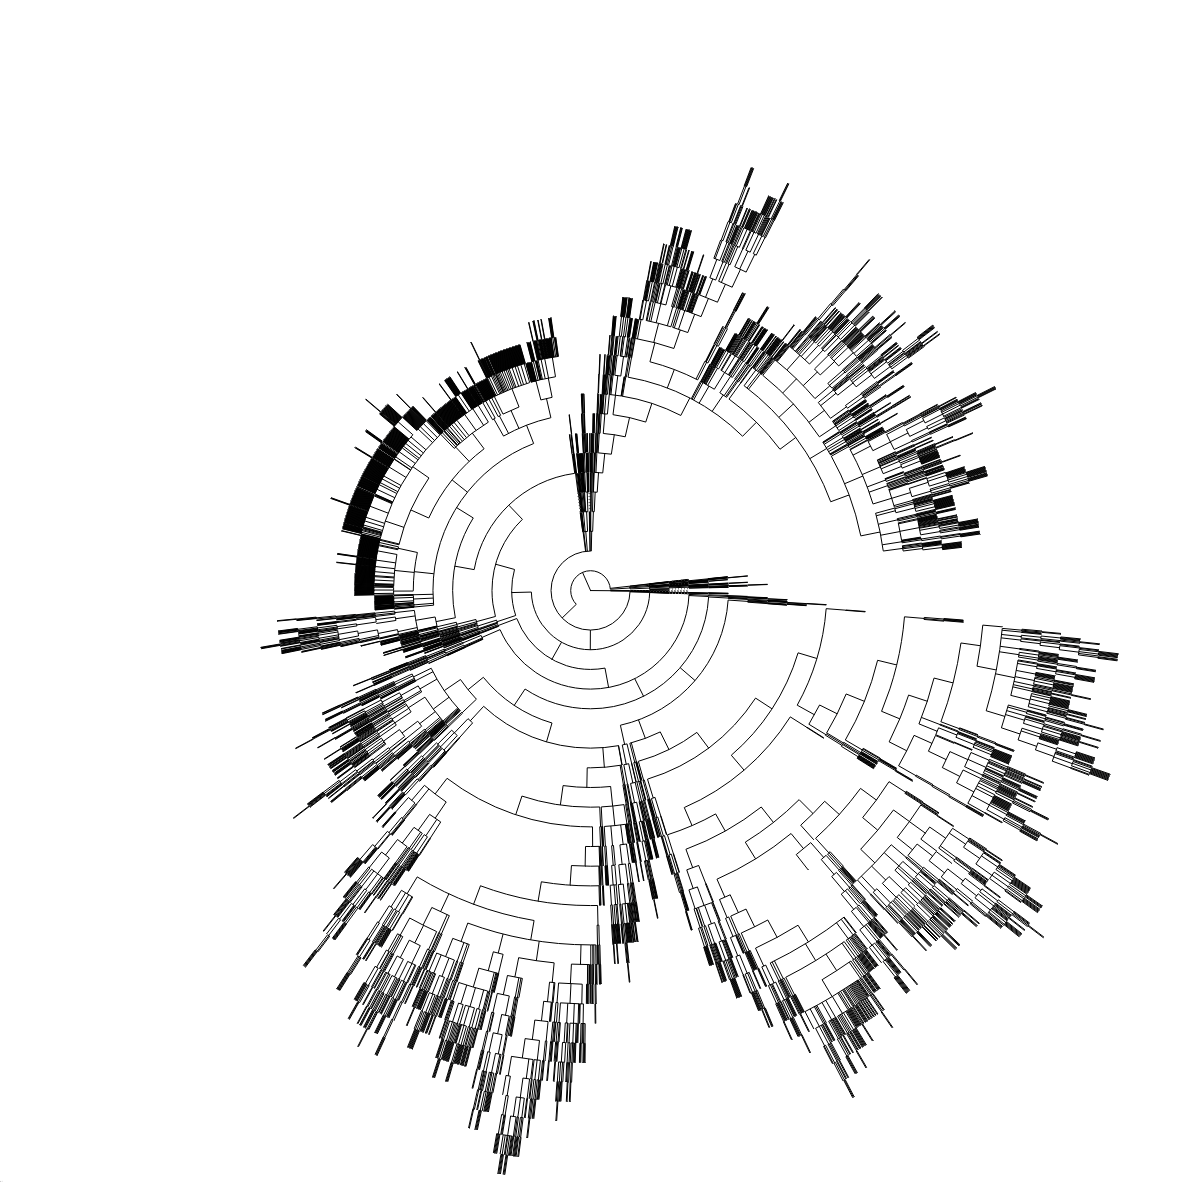

In [110]:
t = Tree(open("../data/plant_cl_sk_clustered_species.phy"), parser = 1)
circular_style = TreeStyle()
circular_style.show_leaf_name = False
circular_style.mode = 'c'  # draw tree in circular mode
circular_style.scale = 100
circular_style.show_branch_length = False
circular_style.show_branch_support = False
t.render('%%inline', w=100, units='mm', tree_style=circular_style, dpi = 300)

In [111]:
t = Tree(open("../data/plant_cl_sk_clustered_species.phy"), parser = 1)
circular_style = TreeStyle()
circular_style.mode = 'r'  # draw tree in circular mode
circular_style.scale = 100
circular_style.branch_vertical_margin = 3
circular_style.show_branch_length = False
circular_style.show_branch_support = False
circular_style.show_leaf_name = False


for node in tqdm.tqdm(t.traverse(), total=total_children(t), desc="Processing nodes"):
    node_from_root = levels_from_root(node)
    node_children = total_children(node)

    if node_children >= 300 or node_from_root < 3:
        if "vir" in node.name or "Viruses incertae" in node.name:
            print("Skipping labels for viruses:")
            print(node.name)
        if node.name != "root" and "vir" not in node.name and "Viruses incertae" not in node.name and node.name != "unclassified sequences" and node.name != "Sphinx1.76-related DNA" and "unidentified" not in node.name:
            size = 500 
            tf = TextFace(f"{str(node.name)} n={total_children_in_data(node)}", fsize=size)
            tf.rotation = 270
            tf.opacity = (total_children_in_data(node) + 25000)/100000
            node.add_face(tf, column=0, position="branch-right")

    # nstyle = NodeStyle()
    # nstyle['size'] = 10
    # node.set_style(nstyle)
    # if node.name in set(interpro_species["Organism"]):
    #     size = 20 #min(500, 10 + node_children // 4)  # Cap size to 80
    #     tf = TextFace(f"{(str(node.name))[:3]}", fsize=size)
    #     tf.rotation = 0
    #     node.add_face(tf, column=0, position="branch-right")

t.render('%%inline', w = 400, units='mm', tree_style=circular_style, dpi = 300)


Processing nodes: 6129it [00:35, 171.72it/s]                         


Skipping labels for viruses:
unclassified bacterial viruses
Skipping labels for viruses:
Heunggongvirae
Skipping labels for viruses:
Myxoma virus
